实验  I的峰值与epsilon0 patch人口一致

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
np.random.seed(2025)

# ---------------------------
# 1. 核心模型函数
# ---------------------------
def compute_epsilon(states, alpha, epsilon0):
    p_A = states[:, 1] + states[:, 2] + states[:, 4]
    return np.where(p_A > alpha, epsilon0, 0.0)

def compute_effective_awareness(n, states, g_i, R):
    N = len(n); M = R.shape[1]
    p_A_res = states[:, 1] + states[:, 2] + states[:, 4]
    tilde_p_A = np.zeros(M)
    for j in range(M):
        flows = n * g_i * R[:, j]
        num = np.sum(flows * p_A_res)
        den = np.sum(flows)
        tilde_p_A[j] = num / den if den > 0 else 0.0
    return tilde_p_A

def compute_awareness_conversion(R, lambda1, tilde_p_A):
    N, M = R.shape
    r = np.zeros(N)
    for i in range(N):
        prod = 1.0
        for j in range(M):
            prod *= (1 - lambda1 * R[i, j] * tilde_p_A[j])
        r[i] = 1 - prod
    return r

def compute_infection_residence(n, states, g_i, beta_U, beta_A):
    n_remain = n * (1 - g_i)
    p_I = states[:, 2]
    N_U = 1 - np.power(1 - beta_U * p_I, n_remain)
    N_A = 1 - np.power(1 - beta_A * p_I, n_remain)
    return N_U, N_A

def compute_infection_transit(n, states, g_i, R, beta_U, beta_A):
    N, M = R.shape
    M_U = np.zeros(M); M_A = np.zeros(M)
    p_I = states[:, 2]
    for j in range(M):
        prod_U, prod_A = 1.0, 1.0
        for k in range(N):
            flow = n[k] * g_i[k] * R[k, j]
            prod_U *= np.power(1 - beta_U * p_I[k], flow)
            prod_A *= np.power(1 - beta_A * p_I[k], flow)
        M_U[j] = 1 - prod_U
        M_A[j] = 1 - prod_A
    return M_U, M_A

def compute_overall_infection(n, states, g_i, R, N_U, N_A, M_U, M_A):
    N = len(n)
    Q_U = np.zeros(N); Q_A = np.zeros(N)
    for i in range(N):
        Q_U[i] = (1 - g_i[i]) * N_U[i] + g_i[i] * np.sum(R[i] * M_U)
        Q_A[i] = (1 - g_i[i]) * N_A[i] + g_i[i] * np.sum(R[i] * M_A)
    return Q_U, Q_A

def update_states(states, r, Q_U, Q_A, mu1, mu2):
    US, AS, AI, UR, AR = [states[:, i] for i in range(5)]
    new = np.zeros_like(states)
    new[:, 0] = US * (1 - r) * (1 - Q_U) + AS * mu1 * (1 - Q_U)
    new[:, 1] = AS * (1 - mu1) * (1 - Q_A) + US * r * (1 - Q_A)
    new[:, 2] = AI * (1 - mu2) + AS * (1 - mu1) * Q_A + AS * mu1 * Q_U + US * (1 - r) * Q_U + US * r * Q_A
    new[:, 3] = AI * mu1 * mu2 + AR * mu1 + UR * (1 - r)
    new[:, 4] = AR * (1 - mu1) + AI * (1 - mu1) * mu2 + UR * r
    new /= np.clip(new.sum(axis=1, keepdims=True), 1e-10, None)
    return new

def update_population(n, states, g_i, epsilon, R, T):
    N, M = R.shape
    X = states * n[:, None]
    F = n * g_i * epsilon
    X_remain = X - (X.T * (g_i * epsilon)).T
    n_remain = n - F

    # 中转站流入
    m = np.zeros(M); m_X = np.zeros((M, 5))
    for j in range(M):
        flows = n * g_i * epsilon * R[:, j]
        m[j] = flows.sum()
        m_X[j] = (X * (g_i * epsilon)[:, None] * R[:, j][:, None]).sum(axis=0)

    # 返回
    flow_return = np.zeros(N); flow_return_X = np.zeros((N, 5))
    for j in range(M):
        flow_return += m[j] * T[:, j]
        flow_return_X += np.outer(T[:, j], m_X[j])

    n_new = n_remain + flow_return
    X_new = X_remain + flow_return_X
    new_states = X_new / np.clip(n_new[:, None], 1e-10, None)
    return n_new, new_states

def main_simulation(Time, N, M, params):
    lambda1, mu1, mu2 = params['lambda1'], params['mu1'], params['mu2']
    beta_U, beta_A = params['beta_U'], params['beta_A']
    g_i = np.full(N, params['theta'] * params['g'])
    # n = np.arange(100, 100 + 50 * N, 50, dtype=int)
    n = np.full(N, 450.0)
    states = np.zeros((N, 5))
    states[:, 0] = 0.99; states[:, 2] = 0.01
    states /= states.sum(axis=1, keepdims=True)

    # 随机网络
    w = np.random.rand(N, M)
    R = w / w.sum(axis=1, keepdims=True)
    T = w / w.sum(axis=0, keepdims=True)

    state_history = np.zeros((Time, N, 5))
    pop_history = np.zeros((Time, N))

    for t in range(Time):
        state_history[t], pop_history[t] = states, n.copy()
        epsilon = compute_epsilon(states, params['alpha'], params['epsilon0'])
        n, states = update_population(n, states, g_i, epsilon, R, T)
        tilde_p_A = compute_effective_awareness(n, states, g_i, R)
        r = compute_awareness_conversion(R, lambda1, tilde_p_A)
        N_U, N_A = compute_infection_residence(n, states, g_i, beta_U, beta_A)
        M_U, M_A = compute_infection_transit(n, states, g_i, R, beta_U, beta_A)
        Q_U, Q_A = compute_overall_infection(n, states, g_i, R, N_U, N_A, M_U, M_A)
        states = update_states(states, r, Q_U, Q_A, mu1, mu2)

    return state_history, pop_history

# ---------------------------
# 2. 重新设计实验：λ₁ 扫描，重复 20 次
# ---------------------------
Time = 140; N = 15; M = 5
epsilon_list = [0.01, 0.3, 0.9]
lambda_values = np.linspace(0.0, 1.0, 21)
num_sims = 20

base_params = {
    'mu1': 0.15, 'mu2': 0.2,
    'beta_U': 0.003, 'beta_A': 0.0015,
    'g': 0.5, 'alpha': 0.3, 'theta': 1,
}

# 存储峰值 AI
results = np.zeros((len(epsilon_list), len(lambda_values), num_sims))

for i, eps in enumerate(epsilon_list):
    for j, lam in enumerate(lambda_values):
        for s in range(num_sims):
            params = base_params.copy()
            params.update({'epsilon0': eps, 'lambda1': lam})
            # 每次模拟获取峰值
            hist, pop_hist = main_simulation(Time, N, M, params)
            peaks = [
                np.sum(hist[t] * pop_hist[t][:, None], axis=0)[2] / np.sum(pop_hist[t])
                for t in range(Time)
            ]
            results[i, j, s] = max(peaks)

# 计算均值与标准差
mean_peak = results.mean(axis=2)



In [3]:
import pandas as pd
data_peak = pd.DataFrame(
    mean_peak,
    index = epsilon_list,
    columns = lambda_values,
).T
print('mean_peak:', mean_peak)
print(data_peak)
print(data_peak[0.01])


mean_peak: [[0.54875504 0.541181   0.53374625 0.52645672 0.5193095  0.5124438
  0.50472229 0.49761879 0.49066202 0.48427606 0.47791568 0.47151031
  0.46453699 0.45986188 0.45356503 0.44779693 0.44188898 0.43827357
  0.43113025 0.42880948 0.42540929]
 [0.54918197 0.54154639 0.53424742 0.52664147 0.51966885 0.5121544
  0.50527493 0.49828327 0.49114418 0.48435849 0.4776983  0.47196575
  0.46565921 0.45944702 0.45381452 0.44800184 0.44263851 0.43860035
  0.43179456 0.43014693 0.42610894]
 [0.55047871 0.54289195 0.53603973 0.52793193 0.52064636 0.51364337
  0.50623138 0.49943769 0.49291301 0.486392   0.48017811 0.47381289
  0.46778766 0.46263416 0.45655869 0.44983522 0.44568116 0.43938156
  0.43453003 0.43114297 0.42760461]]
          0.01      0.30      0.90
0.00  0.548755  0.549182  0.550479
0.05  0.541181  0.541546  0.542892
0.10  0.533746  0.534247  0.536040
0.15  0.526457  0.526641  0.527932
0.20  0.519309  0.519669  0.520646
0.25  0.512444  0.512154  0.513643
0.30  0.504722  0.505275 

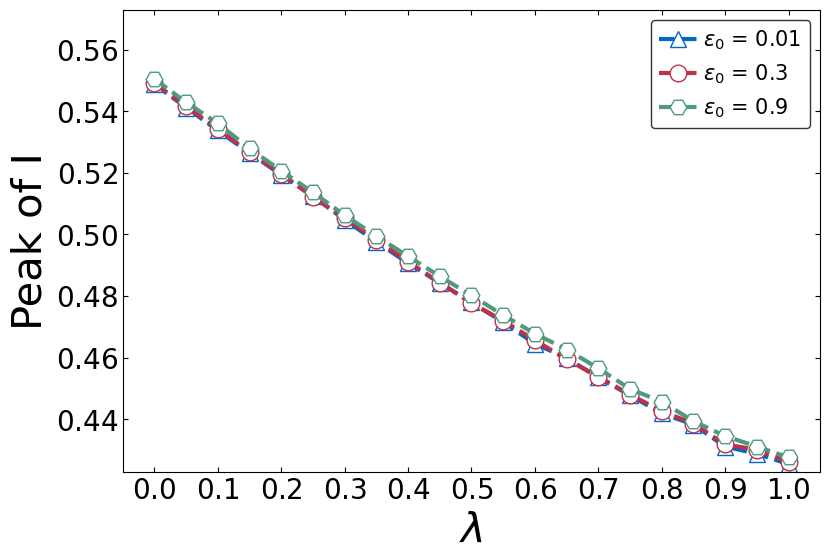

In [10]:
# 绘图
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

# 参数组合 (g, lambda)
param_combinations = [
    {'epsilon': 0.01, 'label': r'$ \epsilon_0 $ = 0.01', 'color': '#0466c8', 'linestyle': '--',  'marker': '^',   'markevery': 1, 'markersize': 12, },
    {'epsilon': 0.3, 'label': r'$ \epsilon_0 $ = 0.3', 'color': '#BF3147', 'linestyle': '--','marker': 'o', 
    'markevery': 1, 'markersize': 12,},
    {'epsilon': 0.9, 'label': r'$ \epsilon_0 $ = 0.9', 'color': '#4E9980', 'linestyle': '--','marker': 'H',
    'markevery': 1, 'markersize': 12, },
]


plt.figure(figsize=(9, 6))
for comb in param_combinations:
    epsilon = comb['epsilon']
    label = comb['label']
    plt.plot(lambda_values, data_peak[epsilon],
              label=label, 
              color=comb['color'], 
              linestyle=comb['linestyle'], 
              marker=comb['marker'],
              mfc= 'white', 
              markevery=comb['markevery'], 
              markersize=comb['markersize'],
              linewidth = 3)
    
legend = plt.legend(
    loc='upper right',
    fontsize='15',
    handletextpad=0.3,    # 图标与文本的间距
    borderpad=0.4,          # 图例内边距
    handlelength=1.8,    # 统一图标宽度
)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(1)
    
# 启用四面刻度
plt.tick_params(
    axis='both',      # 同时控制 x 和 y 轴
    which='both',     # 同时控制主刻度和次刻度
    top=True,         # 显示顶部刻度
    right=True,       # 显示右侧刻度
    labeltop=False,   # 不显示顶部刻度标签（避免重叠）
    labelright=False,  # 不显示右侧刻度标签（避免重叠）
    direction='in',   # 刻度朝内
)

plt.xlabel(r'$\lambda$', fontsize=30)
plt.xticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],[r'$0.0$', r'$0.1$', r'$0.2$', r'$0.3$', r'$0.4$', r'$0.5$', r'$0.6$', r'$0.7$', r'$0.8$', r'$0.9$', r'$1.0$'], fontsize=20)
plt.ylabel('Peak of I', fontsize=30)
plt.yticks([0.44, 0.46, 0.48, 0.5, 0.52, 0.54, 0.56],[r'$0.44$', r'$0.46$', r'$0.48$', r'$0.50$', r'$0.52$', r'$0.54$', r'$0.56$'],fontsize=20)
plt.ylim(0.423, 0.573)

plt.show()
